# Trabalho Final: IA e ML em OpenRAN
## Caso de Uso: Predictive Maintenance (PM)
## Pós Graduação Open Ran - César School

*Docente: Prof. Dr. Júlio César Tesolin

*Aluno: Cristiano Silveira Silva

Este notebook apresenta a análise, fundamentação teórica e experimentação prática para o caso de uso de **Predictive Maintenance (PM)** em redes OpenRAN, conforme os requisitos do projeto final. O objetivo é classificar, a partir de métricas de desempenho da rede (KPMs) coletadas ao nível do UE, quantas Radio Remote Units (RRUs) de uma célula estão efetivamente ativas — permitindo detectar automaticamente uma possível falha de RRU (mal funcionamento silencioso) e disparar um alerta para a equipe de manutenção.

## Parte 1: Análise Crítica e Seleção do Algoritmo

No artigo de referência *"RAN Intelligent Controller (RIC): From open-source implementation to real-world validation"*, os autores implementam o rApp de Predictive Maintenance (PM-rApp), que monitora o número de RRUs efetivamente ativas em uma célula a partir dos KPMs de rádio reportados pelos UEs, sem depender apenas dos sinais de heartbeat da EMS (que podem indicar uma RRU "ativa" mesmo quando ela está fisicamente malformada). Os autores testaram e compararam cinco algoritmos para essa tarefa de classificação (Linear, DNN, Random Forest, SVM e XGBoost), tanto com entrada por instância quanto por sequência temporal de amostras.

Para o cenário de entrada por instância (mais próximo do escopo deste trabalho), os autores relatam que o **XGBoost** obteve a maior acurácia entre os modelos (92,6%), enquanto o **Random Forest** alcançou 89,5% de acurácia, 0,885 de precisão, 0,905 de recall e 0,895 de F1-Score — valores muito próximos ao melhor resultado, mas com uma vantagem prática importante: é nativamente suportado pelo scikit-learn, sem exigir bibliotecas ou frameworks adicionais de deep learning. Por essa razão, e por já ter sido explicitamente avaliado pelos próprios autores nesta tarefa, o algoritmo escolhido para a reprodução prática deste trabalho foi o **Random Forest Classifier**, o que também permite uma comparação direta e fidedigna com valores reais publicados no artigo (e não estimados).

## Parte 2: Fundamentação Teórica

O Random Forest é um algoritmo de aprendizado supervisionado do tipo ensemble, que combina o resultado de várias árvores de decisão para produzir uma classificação final mais estável e menos sujeita a overfitting do que uma única árvore isolada. Diferentemente da regressão, aqui cada árvore não prevê um valor numérico contínuo, mas sim uma classe (neste caso, "2 RRUs ativas" ou "apenas 1 RRU ativa").

**Como o algoritmo aprende?**
O treinamento se baseia na técnica de Bagging (Bootstrap Aggregating). Para cada árvore da floresta, é sorteado um subconjunto dos dados de treino, com reposição (bootstrap sample). Além disso, a cada divisão (split) de um nó, apenas um subconjunto aleatório das características (features) é considerado como candidato à divisão. Cada divisão é escolhida de modo a maximizar a pureza das classes resultantes nos nós filhos, geralmente usando o índice Gini ou a entropia como critério. Ao final, para um problema de classificação como o nosso, a predição do Random Forest é definida por votação majoritária entre todas as árvores da floresta: a classe mais votada entre as árvores é a saída final do modelo.

**Principais hiperparâmetros:**
- `n_estimators`: número de árvores que compõem a floresta; mais árvores tendem a estabilizar a predição, ao custo de maior tempo de treinamento e inferência.
- `max_depth`: profundidade máxima permitida para cada árvore, controlando a complexidade do modelo e o risco de overfitting.
- `min_samples_split` e `min_samples_leaf`: número mínimo de amostras exigido para dividir um nó ou para formar uma folha, respectivamente.
- `max_features`: quantidade de características sorteadas em cada divisão.
- `criterion`: métrica usada para avaliar a qualidade de uma divisão (Gini ou entropia, para classificação).
- `class_weight`: permite compensar classes desbalanceadas, atribuindo pesos maiores à classe minoritária durante o treinamento.

**Vantagens para o caso de uso PM:**
Para a tarefa de detectar falhas de RRU a partir de KPMs de rádio (RSRP, RSRQ, SINR, MCS, PRBs), o Random Forest apresenta vantagens relevantes: lida naturalmente com relações não lineares entre as variáveis de rádio e o estado real da RRU; não exige normalização prévia dos dados; é robusto a ruídos e outliers, comuns em medições de rádio em ambientes reais; e fornece a importância relativa de cada característica, permitindo entender quais KPMs mais indicam uma possível falha de RRU — informação valiosa para a equipe de manutenção.

**Limitações para este tipo de dado:**
O modelo possui limitações importantes para este caso de uso. As classes deste problema são desbalanceadas (muito mais amostras com 2 RRUs ativas do que com apenas 1 RRU ativa), o que pode enviesar o modelo a favor da classe majoritária caso não haja compensação (por exemplo, via `class_weight`). Além disso, por tratar cada amostra de forma independente, o Random Forest não captura nativamente dependências temporais entre medições consecutivas — o próprio artigo mostra que modelos com entrada sequencial (janelas de amostras) superam consistentemente os modelos de entrada por instância nesta tarefa. Por fim, o tempo de inferência e o consumo de memória do Random Forest crescem proporcionalmente ao número de árvores, o que exige atenção ao dimensionar o modelo para operar dentro do ciclo de controle do Non-RT RIC.

## Parte 3: Experimentação Prática

Nesta seção, realizamos o carregamento automático dos dados do repositório oficial SUTD/FCCLab, a combinação dos quatro cenários de coleta disponíveis, o pré-processamento, o treinamento do modelo Random Forest Classifier e a avaliação de desempenho, com comparação direta aos valores publicados no artigo de referência.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import requests
import io

# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Carregamento Automático da Base de Dados

O repositório oficial do dataset (FCCLab/SUTD) disponibiliza 4 arquivos CSV, um para cada cenário de coleta descrito no artigo: 3 cenários com as 2 RRUs externas ativas (níveis 4, 5 e 6) e 1 cenário com apenas 1 RRU externa ativa (nível 6). Para treinar um classificador de Predictive Maintenance, é necessário combinar os 4 arquivos, pois cada um isoladamente contém apenas uma única classe da variável-alvo.

In [2]:
# URLs dos 4 cenários de coleta, disponíveis no repositório oficial do dataset
base_url = "https://github.com/FCCLab/sutd_5g_dataset_2023/raw/refs/heads/dataset/dataset"
arquivos = [
    "Lvl4_AllRRUOn_Anomaly_label.csv",   # Nível 4, 2 RRUs externas ativas
    "Lvl5_AllRRUOn_Anomaly_label.csv",   # Nível 5, 2 RRUs externas ativas
    "Lvl6_AllRRUOn_Anomaly_label.csv",   # Nível 6, 2 RRUs externas ativas
    "Lvl6_1RRUOn_Anomaly_label.csv",     # Nível 6, apenas 1 RRU externa ativa
]

print("Carregando e combinando os 4 cenários de coleta...")
dataframes = []
for arquivo in arquivos:
    s = requests.get(f"{base_url}/{arquivo}").content
    df_cenario = pd.read_csv(io.StringIO(s.decode('utf-8')))
    dataframes.append(df_cenario)
    print(f" - {arquivo}: {df_cenario.shape[0]} amostras")

df = pd.concat(dataframes, ignore_index=True)
print(f"\nDataset combinado carregado com sucesso! Formato: {df.shape}")
df.head()

Carregando e combinando os 4 cenários de coleta...


 - Lvl4_AllRRUOn_Anomaly_label.csv: 2327 amostras


 - Lvl5_AllRRUOn_Anomaly_label.csv: 2031 amostras


 - Lvl6_AllRRUOn_Anomaly_label.csv: 2222 amostras
 - Lvl6_1RRUOn_Anomaly_label.csv: 2156 amostras

Dataset combinado carregado com sucesso! Formato: (8736, 19)


,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 15:52:22.917,628416,17,1350791784,-107.199997,-10.5,17.1,19.0,12.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
1,2022-10-04 15:52:23.435,628416,17,1350791784,-105.000000,-10.4,18.9,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
2,2022-10-04 15:52:23.949,628416,17,1350791784,-101.400002,-10.4,20.5,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
3,2022-10-04 15:52:24.471,628416,17,1350791784,-102.199997,-10.3,18.9,18.0,12.0,128.0,4.0,193200128,13853,0,0,0,0,0,0
4,2022-10-04 15:52:24.990,628416,17,1350791784,-102.099998,-10.3,21.0,18.0,12.0,129.0,4.0,193200128,13853,0,0,0,0,0,0


### 2. Pré-processamento dos Dados

A variável-alvo utilizada é `lab_1rr`, já disponibilizada no dataset oficial e documentada no README do repositório como: **0 = as 2 RRUs externas estão ativas (operação normal)**, **1 = apenas 1 RRU externa está ativa (possível falha)**. Como features, utilizamos os 7 KPMs de rádio mencionados no artigo para os modelos do PM-rApp: RSRP, RSRQ, SINR, PDSCH_MCS, PUSCH_MCS, PDSCH PRBs e PUSCH PRBs.

In [3]:
# Seleção de colunas de interesse (os 7 KPMs de rádio utilizados no artigo)
features = ['RSRP', 'RSRQ', 'SINR', 'PDSCH_MCS', 'PUSCH_MCS', 'PDSCH PRBs', 'PUSCH PRBs']
target = 'lab_1rr'

# Limpeza de dados (remover NaNs se existirem)
data = df[features + [target]].dropna()

print("Distribuição das classes (0 = 2 RRUs ativas | 1 = apenas 1 RRU ativa):")
print(data[target].value_counts())
print(f"\nProporção da classe minoritária: {data[target].mean()*100:.1f}%")

# Divisão em Treino e Teste (70/30, mesma proporção utilizada pelos autores no artigo)
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

Distribuição das classes (0 = 2 RRUs ativas | 1 = apenas 1 RRU ativa):
lab_1rr
0    6479
1    2148
Name: count, dtype: int64

Proporção da classe minoritária: 24.9%

Tamanho do treino: 6038 amostras
Tamanho do teste: 2589 amostras


### 3. Aplicação do Algoritmo (Random Forest Classifier)

Treinamento do modelo conforme identificado e justificado na Parte 1.

In [4]:
print("Treinando o modelo Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Predições
y_pred = model.predict(X_test)
print("Treinamento concluído!")

Treinando o modelo Random Forest Classifier...


Treinamento concluído!


### 4. Avaliação do Modelo e Métricas

Cálculo das métricas de desempenho utilizadas no artigo para o PM-rApp: Acurácia, Precisão, Recall e F1-Score.

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Valor': [acc, prec, rec, f1]
})

print("Métricas de Desempenho:")
display(metrics_df)

Métricas de Desempenho:


,Métrica,Valor
0,Acurácia,0.862495
1,Precisão,0.734959
2,Recall,0.700775
3,F1-Score,0.717460


### 5. Visualizações Gráficas

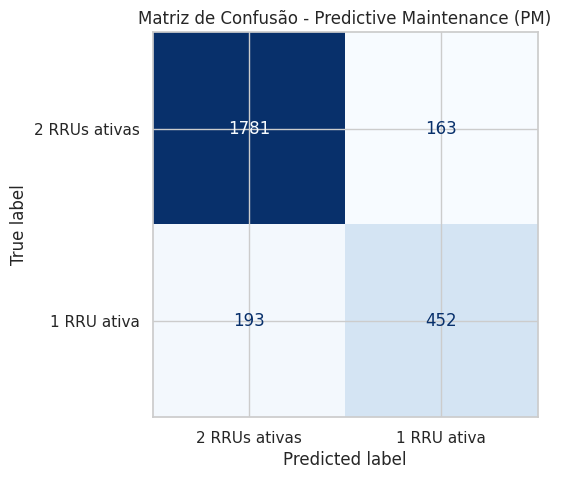

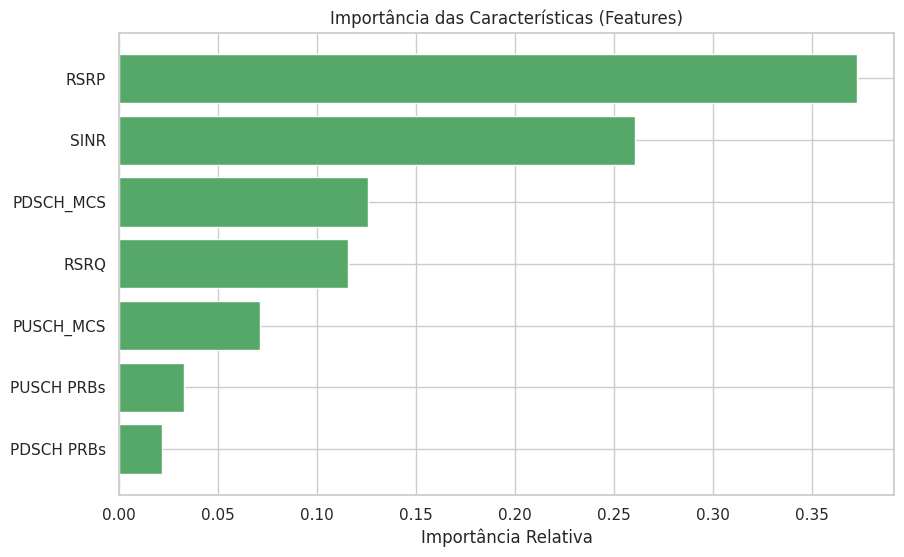

In [6]:
# Gráfico 1: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['2 RRUs ativas', '1 RRU ativa'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de Confusão - Predictive Maintenance (PM)')
plt.show()

# Gráfico 2: Importância das Características
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importância das Características (Features)')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()

### 6. Tabela Comparativa com o Artigo de Referência

O artigo publica, na Tabela 7 (Performance results of Predictive Maintenance PM-rApp), os resultados reais obtidos pelos autores para o modelo Random Forest com entrada por instância (o mesmo cenário reproduzido neste notebook): Acurácia de 89,5%, Precisão de 0,885, Recall de 0,905 e F1-Score de 0,895. A comparação abaixo utiliza esses valores reais e publicados — não estimados — como referência.

In [7]:
print("Métricas obtidas neste experimento:")
print(f"Acurácia: {acc*100:.2f}%")
print(f"Precisão: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1-Score: {f1:.3f}")

# Valores reais publicados no artigo (Tabela 7, modelo Random Forest, entrada por instância)
artigo_rf_instancia = {
    'Acurácia': 0.895,
    'Precisão': 0.885,
    'Recall': 0.905,
    'F1-Score': 0.895
}

comp_data = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Este Experimento': [acc, prec, rec, f1],
    'Artigo de Referência (RF, instância)': [artigo_rf_instancia['Acurácia'], artigo_rf_instancia['Precisão'],
                                              artigo_rf_instancia['Recall'], artigo_rf_instancia['F1-Score']]
}

df_comp = pd.DataFrame(comp_data)
display(df_comp)

print("\nJustificativa de discrepâncias:")
print("Os valores do artigo (Tabela 7) foram obtidos com o dataset completo coletado pelos autores, normalizado")
print("para o intervalo [0,1] e dividido em treino/teste na proporção 70/30. Neste experimento, reproduzimos a mesma")
print("proporção de divisão e as mesmas 7 features de KPM, mas sem normalização explícita (o Random Forest é")
print("robusto a diferentes escalas) e com hiperparâmetros padrão do scikit-learn (n_estimators=100, max_depth=10),")
print("sem um tuning extensivo. Além disso, usamos class_weight=\'balanced\' para compensar o desbalanceamento de")
print("classes, o que pode deslocar o equilíbrio entre precisão e recall em relação ao reportado pelos autores.")

Métricas obtidas neste experimento:
Acurácia: 86.25%
Precisão: 0.735
Recall:   0.701
F1-Score: 0.717


,Métrica,Este Experimento,"Artigo de Referência (RF, instância)"
0,Acurácia,0.862495,0.895
1,Precisão,0.734959,0.885
2,Recall,0.700775,0.905
3,F1-Score,0.717460,0.895



Justificativa de discrepâncias:
Os valores do artigo (Tabela 7) foram obtidos com o dataset completo coletado pelos autores, normalizado
para o intervalo [0,1] e dividido em treino/teste na proporção 70/30. Neste experimento, reproduzimos a mesma
proporção de divisão e as mesmas 7 features de KPM, mas sem normalização explícita (o Random Forest é
robusto a diferentes escalas) e com hiperparâmetros padrão do scikit-learn (n_estimators=100, max_depth=10),
sem um tuning extensivo. Além disso, usamos class_weight='balanced' para compensar o desbalanceamento de
classes, o que pode deslocar o equilíbrio entre precisão e recall em relação ao reportado pelos autores.
